<a href="https://colab.research.google.com/github/hjiwoong/bigdata/blob/main/%EC%8B%9C%EA%B3%84%EC%97%B4%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 환경설정

In [1]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt #그래프 그리는 모듈
import matplotlib.font_manager as fm #폰트 관리하는 모듈

#드라이브 내 폰트 경로
font_path = "/content/drive/MyDrive/KWU/bigdata/dataPreProcessing/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
mpl.rc('font',family = 'NanumGothic') #matplolib 기본 폰트로 설정
plt.rcParams['font.family'] = "NanumGothic"
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans_serif']
plt.rcParams['axes.unicode_minus'] = False #마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ",plt.rcParams['font.family']) #현재 적용된 폰트 이름 출력

Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #모든 경고 메시지를 무시하도록 설정

### datetime 객체 활용

In [3]:
from datetime import datetime

#현재 날짜 / 시간 가져오기
t1 = datetime.now()
print('현재시각:',t1)

#원하는 날짜 / 시간으로 직접 생성
t2 = datetime(2020,1,2,9,0,0) #datetime(연, 월, 일, 시, 분, 초) 형식
print('삼성전자 데이터 시작일:', t2)

#두 datetime 객체의 차이 계산
diff = t1 - t2
print('경과시간:', diff)
print('경과 일수:', diff.days) #정수만 추출
print('자료형:', type(diff))

현재시각: 2026-03-23 07:46:54.502206
삼성전자 데이터 시작일: 2020-01-02 09:00:00
경과시간: 2271 days, 22:46:54.502206
경과 일수: 2271
자료형: <class 'datetime.timedelta'>


### datetime으로 변환

In [4]:
#CSV파일 경로
DATA_PATH = '/content/drive/MyDrive/KWU/bigdata/eda/samsung_stock.csv'
print('준비 완료')

준비 완료


In [5]:
#변환 전
df = pd.read_csv(DATA_PATH)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1304 non-null   object
 1   Open    1304 non-null   int64 
 2   High    1304 non-null   int64 
 3   Low     1304 non-null   int64 
 4   Close   1304 non-null   int64 
 5   Volume  1304 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 61.3+ KB


In [6]:
#변환 후
df['date_dt'] = pd.to_datetime(df['Date'])
df['data_fmt'] = pd.to_datetime(df['Date'],format='%Y-%m-%d')
df['data_yf'] = pd.to_datetime(df['Date'], yearfirst=True)

df.head()

,Date,Open,High,Low,Close,Volume,date_dt,data_fmt,data_yf
0,2020-01-02,54640,56325,54309,55000,13077813,2020-01-02,2020-01-02,2020-01-02
1,2020-01-03,55625,56869,54386,55409,12694420,2020-01-03,2020-01-03,2020-01-03
2,2020-01-06,55124,56452,54018,55294,20269936,2020-01-06,2020-01-06,2020-01-06
3,2020-01-07,56363,57470,55053,55832,14850350,2020-01-07,2020-01-07,2020-01-07
4,2020-01-08,57268,57737,56011,57107,21399173,2020-01-08,2020-01-08,2020-01-08


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1304 non-null   object        
 1   Open      1304 non-null   int64         
 2   High      1304 non-null   int64         
 3   Low       1304 non-null   int64         
 4   Close     1304 non-null   int64         
 5   Volume    1304 non-null   int64         
 6   date_dt   1304 non-null   datetime64[ns]
 7   data_fmt  1304 non-null   datetime64[ns]
 8   data_yf   1304 non-null   datetime64[ns]
dtypes: datetime64[ns](3), int64(5), object(1)
memory usage: 91.8+ KB


In [8]:
#csv 로드 시 바로 datetime 변환
df = pd.read_csv(DATA_PATH, parse_dates=['Date']) #'Date'열은 즉시 datetime64[ns]타입으로 변환
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-02,54640,56325,54309,55000,13077813
1,2020-01-03,55625,56869,54386,55409,12694420
2,2020-01-06,55124,56452,54018,55294,20269936
3,2020-01-07,56363,57470,55053,55832,14850350
4,2020-01-08,57268,57737,56011,57107,21399173


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1304 non-null   datetime64[ns]
 1   Open    1304 non-null   int64         
 2   High    1304 non-null   int64         
 3   Low     1304 non-null   int64         
 4   Close   1304 non-null   int64         
 5   Volume  1304 non-null   int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 61.3 KB


In [10]:
#단일 Timetamp에서 속성 추출
ts = pd.to_datetime('2026-03-19')
print('Timestamp:', ts)
print('연도:',ts.year)
print('월:',ts.month)
print('일:',ts.day)
print('요일:',ts.weekday())
print('분기:',ts.quarter)
print('시:',ts.hour)
print('분:',ts.minute)

Timestamp: 2026-03-19 00:00:00
연도: 2026
월: 3
일: 19
요일: 3
분기: 1
시: 0
분: 0


In [11]:
#dt 접근자로 열 전체에 datetime 속성 적용, dt는 datetime64[ns] 타입의 Series에만 사용
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday #(0=월 ~ 6=일)
df['quarter'] = df['Date'].dt.quarter
df['dayofyear'] = df['Date'].dt.dayofyear #연중 누적 일수(dayofyearm 1~365)를 출력

print('추출된 열 자료형:')
print(df[['year','month','day','weekday','quarter','dayofyear']].dtypes)

추출된 열 자료형:
year         int32
month        int32
day          int32
weekday      int32
quarter      int32
dayofyear    int32
dtype: object


In [12]:
df[['year','month','day','weekday','quarter','dayofyear']]

,year,month,day,weekday,quarter,dayofyear
0,2020,1,2,3,1,2
1,2020,1,3,4,1,3
2,2020,1,6,0,1,6
3,2020,1,7,1,1,7
4,2020,1,8,2,1,8
...,...,...,...,...,...,...
1299,2024,12,25,2,4,360
1300,2024,12,26,3,4,361
1301,2024,12,27,4,4,362
1302,2024,12,30,0,4,365


### Yahoo Finance에서 주식 데이터를 다운로드

In [13]:
%pip install yfinance -q
import yfinance as yf
df = yf.download('005930.KS',start='2020-01-01',end='2026-03-19') #삼성전자 종목 코드
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2026-03-12,187900.0,190000.0,185900.0,186600.0,20440753
2026-03-13,183500.0,186200.0,179900.0,180000.0,19566331
2026-03-16,188700.0,189000.0,183600.0,184600.0,19747901
2026-03-17,193900.0,198000.0,193100.0,198000.0,20300082
2026-03-18,208500.0,209000.0,199700.0,200500.0,25148481


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1520 entries, 2020-01-02 to 2026-03-18
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   1520 non-null   float64
 1   (High, 005930.KS)    1520 non-null   float64
 2   (Low, 005930.KS)     1520 non-null   float64
 3   (Open, 005930.KS)    1520 non-null   float64
 4   (Volume, 005930.KS)  1520 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.2 KB


In [15]:
#멀티인덱스 평탄화 및 이름 변경
df_f = df[['Open','High','Low','Close','Volume']].copy()
if isinstance(df_f.columns, pd.MultiIndex):
  df_f.columns = df_f.columns.droplevel(1) #MultiIndex의 두번째 레벨을 제거

df_f.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1520 entries, 2020-01-02 to 2026-03-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1520 non-null   float64
 1   High    1520 non-null   float64
 2   Low     1520 non-null   float64
 3   Close   1520 non-null   float64
 4   Volume  1520 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.2 KB


In [16]:
df_f.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,47728.892451,48158.882473,47298.902429,47470.898438,12993228
2020-01-03,48158.880631,48674.868637,47212.902618,47728.890625,15422255
2020-01-06,47212.902618,47814.888626,46954.908615,47728.890625,10278951
2020-01-07,47900.892613,48502.878696,47814.894601,47986.890625,10009778
2020-01-08,48330.875289,49362.851274,48072.881293,48846.863281,23501171


In [17]:
#DatetimeIndex에서 시간 정보 추출
df_f['year'] = df_f.index.year
df_f['month'] = df_f.index.month
df_f['day'] = df_f.index.day
df_f['weekday'] = df_f.index.weekday
df_f['quarter'] = df_f.index.quarter
df_f['dayofyear'] = df_f.index.dayofyear

df_f.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1520 entries, 2020-01-02 to 2026-03-18
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1520 non-null   float64
 1   High       1520 non-null   float64
 2   Low        1520 non-null   float64
 3   Close      1520 non-null   float64
 4   Volume     1520 non-null   int64  
 5   year       1520 non-null   int32  
 6   month      1520 non-null   int32  
 7   day        1520 non-null   int32  
 8   weekday    1520 non-null   int32  
 9   quarter    1520 non-null   int32  
 10  dayofyear  1520 non-null   int32  
dtypes: float64(4), int32(6), int64(1)
memory usage: 106.9 KB


In [18]:
df_f.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear
Date,,,,,,,,,,,
2020-01-02,47728.892451,48158.882473,47298.902429,47470.898438,12993228,2020,1,2,3,1,2
2020-01-03,48158.880631,48674.868637,47212.902618,47728.890625,15422255,2020,1,3,4,1,3
2020-01-06,47212.902618,47814.888626,46954.908615,47728.890625,10278951,2020,1,6,0,1,6
2020-01-07,47900.892613,48502.878696,47814.894601,47986.890625,10009778,2020,1,7,1,1,7
2020-01-08,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8


In [19]:
#요일별 평균 종가 분석
weekday_names = {0:'월',1:'화',2:'수',3:'목',4:'금'}
df_f['weekday_name'] = df_f['weekday'].map(weekday_names) #요일 번호 -> 한글 매핑
avg_by_weekday = df_f.groupby('weekday_name')['Close'].mean().round(2)
print('요일별 평균 종가(원)')
print(avg_by_weekday)

요일별 평균 종가(원)
weekday_name
금    67626.07
목    67251.58
수    67431.59
월    67039.37
화    67612.87
Name: Close, dtype: float64


In [20]:
df_f

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name
Date,,,,,,,,,,,,
2020-01-02,47728.892451,48158.882473,47298.902429,47470.898438,12993228,2020,1,2,3,1,2,목
2020-01-03,48158.880631,48674.868637,47212.902618,47728.890625,15422255,2020,1,3,4,1,3,금
2020-01-06,47212.902618,47814.888626,46954.908615,47728.890625,10278951,2020,1,6,0,1,6,월
2020-01-07,47900.892613,48502.878696,47814.894601,47986.890625,10009778,2020,1,7,1,1,7,화
2020-01-08,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-12,186600.000000,190000.000000,185900.000000,187900.000000,20440753,2026,3,12,3,1,71,목
2026-03-13,180000.000000,186200.000000,179900.000000,183500.000000,19566331,2026,3,13,4,1,72,금
2026-03-16,184600.000000,189000.000000,183600.000000,188700.000000,19747901,2026,3,16,0,1,75,월


In [21]:
#시간 간격 계산하기
#데이터의 가장 오래된 날짜(기준일) 구하기
base_date = df_f.index.min()
print('데이터 시작일(기준일):', base_date)

#각 행의 날짜 - 기준일 = 경과 기간(timedelta)
df_f['days_elapsed'] = df_f.index - base_date
print('경과 기간 자료형:',df_f['days_elapsed'].dtype)
df_f[['days_elapsed']].head()

데이터 시작일(기준일): 2020-01-02 00:00:00
경과 기간 자료형: timedelta64[ns]


Price,days_elapsed
Date,
2020-01-02,0 days
2020-01-03,1 days
2020-01-06,4 days
2020-01-07,5 days
2020-01-08,6 days


In [22]:
#timedelta -> 정수 (일수)로 변환
df_f['days_int'] = df_f['days_elapsed'].dt.days
print('정수(일수) 자료형:', df_f['days_int'].dtype)
df_f[['days_int']]

정수(일수) 자료형: int64


Price,days_int
Date,
2020-01-02,0
2020-01-03,1
2020-01-06,4
2020-01-07,5
2020-01-08,6
...,...
2026-03-12,2261
2026-03-13,2262
2026-03-16,2265


In [23]:
#거래일(영업일) 번호 생성(0부터 순서대로)
df_f['trading_day'] = range(len(df_f))
print('경과 달력 일수:', df_f['days_int'].iloc[-1])
print('거래일 순번:', df_f['trading_day'].iloc[-1]) #공휴일 제외

경과 달력 일수: 2267
거래일 순번: 1519


In [24]:
df_f[['trading_day']]

Price,trading_day
Date,
2020-01-02,0
2020-01-03,1
2020-01-06,2
2020-01-07,3
2020-01-08,4
...,...
2026-03-12,1515
2026-03-13,1516
2026-03-16,1517


### datetime 객체의 메서드 활용하기

In [25]:
#연도별 평균 종가
yearly_colse = df_f.groupby(df_f.index.year)['Close'].mean().round(0)
print('연도별 평균 종가 \n',yearly_colse)

연도별 평균 종가 
 Date
2020     49724.0
2021     71685.0
2022     58998.0
2023     63856.0
2024     69072.0
2025     70635.0
2026    168284.0
Name: Close, dtype: float64


In [26]:
#연도 x 분기별 평균 종가
quarterly_close = df_f.groupby([df_f.index.year, df_f.index.quarter])['Close'].mean().round(0)
print('연도 X 분기별 평균 종가 \n', quarterly_close)
print(type(quarterly_close))

연도 X 분기별 평균 종가 
 Date  Date
2020  1        48076.0
      2        43745.0
      3        49339.0
      4        57782.0
2021  1        75473.0
      2        73918.0
      3        70537.0
      4        66973.0
2022  1        67249.0
      2        60018.0
      3        54246.0
      4        55105.0
2023  1        57566.0
      2        64084.0
      3        66124.0
      4        67781.0
2024  1        71536.0
      2        76147.0
      3        73863.0
      4        54780.0
2025  1        54644.0
      2        55932.0
      3        69998.0
      4       101998.0
2026  1       168284.0
Name: Close, dtype: float64
<class 'pandas.core.series.Series'>


In [27]:
#멀티 인덱스의 각 인덱스 이름 변경
quarterly_close_renamed = quarterly_close.rename_axis(index={'year','quarter'})
quarterly_close_df = quarterly_close_renamed.reset_index()
print(type(quarterly_close_df))
quarterly_close_df

<class 'pandas.core.frame.DataFrame'>


,quarter,year,Close
0,2020,1,48076.0
1,2020,2,43745.0
2,2020,3,49339.0
3,2020,4,57782.0
4,2021,1,75473.0
5,2021,2,73918.0
6,2021,3,70537.0
7,2021,4,66973.0
8,2022,1,67249.0
9,2022,2,60018.0


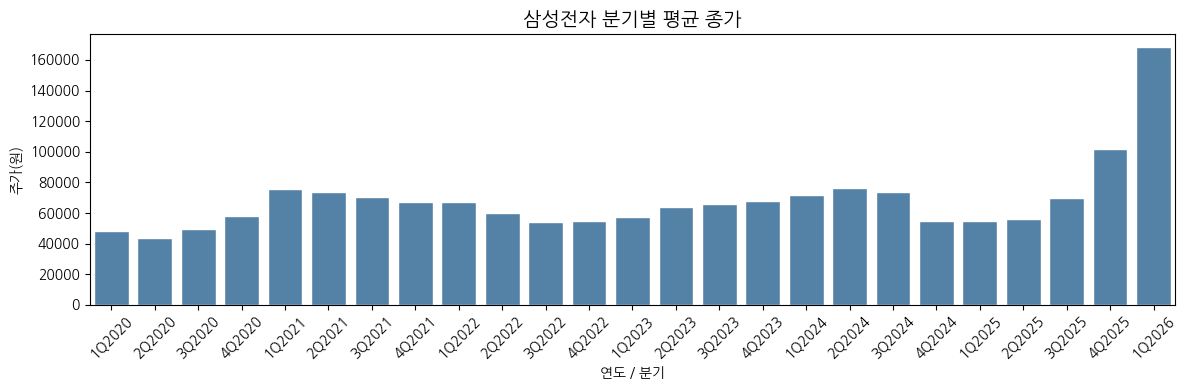

In [28]:
#연도 x 분기별 평균 종가 시각화
fig, axes = plt.subplots(figsize=(12,4))

quarterly_close_df['year_quarter'] = quarterly_close_df['year'].astype(str)+'Q'+quarterly_close_df['quarter'].astype(str)

sns.barplot(x='year_quarter', y='Close', data=quarterly_close_df, ax=axes, color='steelblue', edgecolor='white')
axes.set_title('삼성전자 분기별 평균 종가', fontsize=14)
axes.set_xlabel('연도 / 분기')
axes.set_ylabel('주가(원)')
axes.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#DatetimeIndex 상세 정보 확인
print('인덱스 정보:', df_f.index)
print('전체 기간:', df_f.index.min(), '~', df_f.index.max())
print('총 거래일 수:',len(df_f))

인덱스 정보: DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10',
               '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16',
               '2026-03-17', '2026-03-18'],
              dtype='datetime64[ns]', name='Date', length=1520, freq=None)
전체 기간: 2020-01-02 00:00:00 ~ 2026-03-18 00:00:00
총 거래일 수: 1520


### 시간별 데이터 추출

In [30]:
#연도 전체 추출
df_2025 = df_f.loc['2025']
print('2025년 데이터:', df_2025.shape)
df_2025.head()

2025년 데이터: (241, 15)


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_elapsed,days_int,trading_day
Date,,,,,,,,,,,,,,,
2025-01-02,51587.310803,52468.308521,51195.756262,52272.531250,16630538,2025,1,2,3,1,2,목,1827 days,1827,1229
2025-01-03,51685.199793,53936.638421,51685.199793,53251.417969,19318046,2025,1,3,4,1,3,금,1828 days,1828,1230
2025-01-06,53251.420394,55013.415921,53153.531753,54719.750000,19034284,2025,1,6,0,1,6,월,1831 days,1831,1231
2025-01-07,55600.745600,56090.188783,54230.304688,54230.304688,17030235,2025,1,7,1,1,7,화,1832 days,1832,1232
2025-01-08,53642.967905,56285.960849,53545.079277,56090.183594,26593553,2025,1,8,2,1,8,수,1833 days,1833,1233


In [31]:
#특정 연~월 추출
df_2025_12=df_f.loc['2025-12']
print('2025년 12월 데이터:',df_2025_12.shape)
df_2025_12.head()

2025년 12월 데이터: (21, 15)


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_elapsed,days_int,trading_day
Date,,,,,,,,,,,,,,,
2025-12-01,101506.562035,102302.691933,99416.721052,100312.367188,10905526,2025,12,1,0,4,335,월,2160 days,2160,1449
2025-12-02,100710.431848,102999.305300,100511.399374,102899.789062,13649487,2025,12,2,1,4,336,화,2161 days,2161,1450
2025-12-03,104193.501226,104989.631130,103496.887560,103994.468750,14697927,2025,12,3,2,4,337,수,2162 days,2162,1451
2025-12-04,103397.367686,104591.562500,102700.754044,104591.562500,11931145,2025,12,4,3,4,338,목,2163 days,2163,1452
2025-12-05,104790.598197,107875.601562,104093.984534,107875.601562,19755571,2025,12,5,4,4,339,금,2164 days,2164,1453


2022년 상반기 데이터: (119, 15)


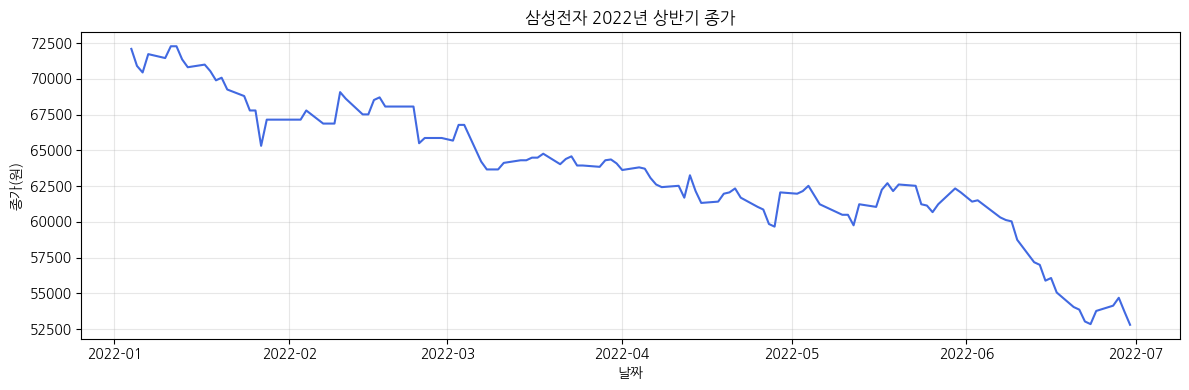

In [32]:
#날짜 범위 슬라이싱(loc[] 또는 직접 슬라이싱)
df_2022 = df_f['2022-01-01':'2022-06-30']
print('2022년 상반기 데이터:',df_2022.shape)

fig, axes = plt.subplots(figsize=(12,4))
sns.lineplot(x=df_2022.index, y='Close', data=df_2022, ax=axes, color='royalblue', linewidth=1.5)
axes.set_title('삼성전자 2022년 상반기 종가')
axes.set_xlabel('날짜')
axes.set_ylabel('종가(원)')
axes.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
#dt 속성으로 조건 추출
mask = (df_f.index.year == 2026) & (df_f.index.month == 2)
df_2026_2 = df_f[mask]
print('dt 속성으로 추출한 2026년 2월:', df_2026_2.shape)

dt 속성으로 추출한 2026년 2월: (17, 15)


In [34]:
#TimedeltaIndex 생성 및 추출
df_td = df_f.copy()
df_td['day_elapsed'] = df_td.index - df_td.index.min()

df_td = df_td.set_index('days_elapsed')
print('인덱스 자료형:',type(df_td.index))
df_td.head()

인덱스 자료형: <class 'pandas.core.indexes.timedeltas.TimedeltaIndex'>


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_int,trading_day,day_elapsed
days_elapsed,,,,,,,,,,,,,,,
0 days,47728.892451,48158.882473,47298.902429,47470.898438,12993228,2020,1,2,3,1,2,목,0,0,0 days
1 days,48158.880631,48674.868637,47212.902618,47728.890625,15422255,2020,1,3,4,1,3,금,1,1,1 days
4 days,47212.902618,47814.888626,46954.908615,47728.890625,10278951,2020,1,6,0,1,6,월,4,2,4 days
5 days,47900.892613,48502.878696,47814.894601,47986.890625,10009778,2020,1,7,1,1,7,화,5,3,5 days
6 days,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수,6,4,6 days


In [35]:
#Timedeltaindex로 기간 범위 추출
df_30day=df_td['0 days':'30 days']
print('첫 30일간 거래일 수:', len(df_30day))
df_30day.head()

첫 30일간 거래일 수: 20


Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_int,trading_day,day_elapsed
days_elapsed,,,,,,,,,,,,,,,
0 days,47728.892451,48158.882473,47298.902429,47470.898438,12993228,2020,1,2,3,1,2,목,0,0,0 days
1 days,48158.880631,48674.868637,47212.902618,47728.890625,15422255,2020,1,3,4,1,3,금,1,1,1 days
4 days,47212.902618,47814.888626,46954.908615,47728.890625,10278951,2020,1,6,0,1,6,월,4,2,4 days
5 days,47900.892613,48502.878696,47814.894601,47986.890625,10009778,2020,1,7,1,1,7,화,5,3,5 days
6 days,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수,6,4,6 days


### 시간 범위 다루기

In [36]:
#reindex()로 누락 날짜 채우기
df_2022_close = df_f.loc['2022','Close']
print('원본 거래일 수:', len(df_2022_close))
display(df_2022_close)
full_range = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D') #시간 주기를 '일(Day)' 단위로 설정

df_2022_full = df_2022_close.reindex(full_range)
display(df_2022_full)
print('reindex 후 전체 날짜 수:', len(df_2022_full))
print('NaN개수 (주말+공휴일):', df_2022_full.isna().sum())

weekend_check = df_2022_full[df_2022_full.isna()].index
print('누락 날짜 샘플(주말):')
print(weekend_check[:5])

원본 거래일 수: 244


,Close
Date,
2022-01-04,72089.242188
2022-01-05,70898.445312
2022-01-06,70440.445312
2022-01-07,71722.835938
2022-01-10,71448.039062
...,...
2022-12-23,54191.640625
2022-12-26,54005.093750
2022-12-27,54191.640625


,Close
2022-01-01,NaN
2022-01-02,NaN
2022-01-03,NaN
2022-01-04,72089.242188
2022-01-05,70898.445312
...,...
2022-12-27,54191.640625
2022-12-28,53122.621094
2022-12-29,51902.488281
2022-12-30,NaN


reindex 후 전체 날짜 수: 365
NaN개수 (주말+공휴일): 121
누락 날짜 샘플(주말):
DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-08',
               '2022-01-09'],
              dtype='datetime64[ns]', freq=None)


In [37]:
#열 방향으로 값 옯기기
#shift()를 활용한 시계열 이동 및 수익률 계산
df_s = df_f[['Close']].copy()

df_s['Close_lag1'] = df_s['Close'].shift(1) #데이터를 아래로 1칸 이동
df_s['Close_lag5'] = df_s['Close'].shift(5) #데이터를 아래로 5칸 이동
df_s['Close_lead1'] = df_s['Close'].shift(-1) #데이터를 위로 1칸 이동

print('shift 결과 \n', df_s.head(10))

shift 결과 
 Price              Close    Close_lag1    Close_lag5   Close_lead1
Date                                                              
2020-01-02  47470.898438           NaN           NaN  47728.890625
2020-01-03  47728.890625  47470.898438           NaN  47728.890625
2020-01-06  47728.890625  47728.890625           NaN  47986.890625
2020-01-07  47986.890625  47728.890625           NaN  48846.863281
2020-01-08  48846.863281  47986.890625           NaN  50394.828125
2020-01-09  50394.828125  48846.863281  47470.898438  51168.824219
2020-01-10  51168.824219  50394.828125  47728.890625  51598.800781
2020-01-13  51598.800781  51168.824219  47728.890625  51598.800781
2020-01-14  51598.800781  51598.800781  47986.890625  50738.828125
2020-01-15  50738.828125  51598.800781  48846.863281  52200.792969


In [38]:
#일간 수익률 계산 (shift 활용의 가장 흔한 사례)
df_s['return_shift'] = df_s['Close'] / df_s['Close'].shift(1) -1 #오늘 종가 105/어제 종가 100 -1 = 0.05 수익률 계산
df_s['return_pct'] = df_s['Close'].pct_change() #수익률 자동 계산 함수
print('두 방법 차이 합계:',(df_s['return_shift'] - df_s['return_pct']))
df_s[['Close', 'return_shift', 'return_pct']]

두 방법 차이 합계: Date
2020-01-02    NaN
2020-01-03    0.0
2020-01-06    0.0
2020-01-07    0.0
2020-01-08    0.0
             ... 
2026-03-12    0.0
2026-03-13    0.0
2026-03-16    0.0
2026-03-17    0.0
2026-03-18    0.0
Length: 1520, dtype: float64


Price,Close,return_shift,return_pct
Date,,,
2020-01-02,47470.898438,NaN,NaN
2020-01-03,47728.890625,0.005435,0.005435
2020-01-06,47728.890625,0.000000,0.000000
2020-01-07,47986.890625,0.005406,0.005406
2020-01-08,48846.863281,0.017921,0.017921
...,...,...,...
2026-03-12,187900.000000,-0.011053,-0.011053
2026-03-13,183500.000000,-0.023417,-0.023417
2026-03-16,188700.000000,0.028338,0.028338


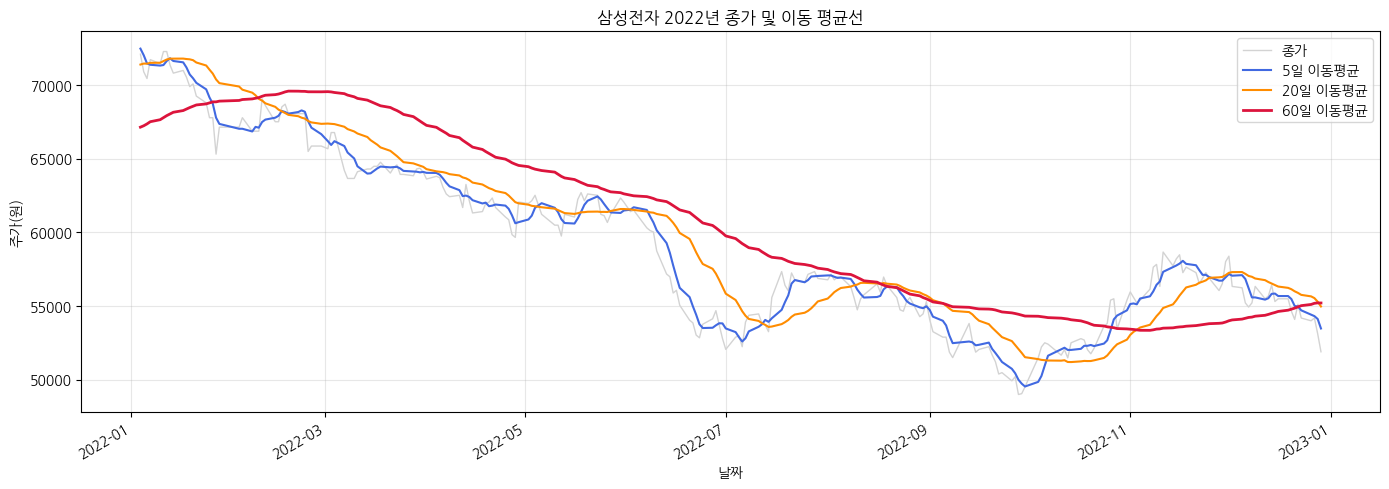

In [39]:
#이동 평균 (Moving Average) - shift 응용
df_ma = df_f[['Close']].copy()

df_ma['MA5'] = df_ma['Close'].rolling(window=5).mean() #현재 행을 기준으로 직전 5개의 데이터(윈도우)를 그룹화
df_ma['MA20'] = df_ma['Close'].rolling(window=20).mean()
df_ma['MA60'] = df_ma['Close'].rolling(window=60).mean() #60일간의 평균을 내면 전체적인 가격의 방향성(추세)을 더 쉽게 파악

#2022년 이동평균 시각화 - matplotlib
fig, axes = plt.subplots(figsize=(14,5))
df_ma.loc['2022','Close'].plot(ax=axes, color = 'lightgray', linewidth=1, label='종가')
df_ma.loc['2022','MA5'].plot(ax=axes, color = 'royalblue', linewidth=1.5, label='5일 이동평균')
df_ma.loc['2022','MA20'].plot(ax=axes, color = 'darkorange', linewidth=1.5, label='20일 이동평균')
df_ma.loc['2022','MA60'].plot(ax=axes, color = 'crimson', linewidth=2, label='60일 이동평균')

axes.set_title('삼성전자 2022년 종가 및 이동 평균선')
axes.set_xlabel('날짜')
axes.set_ylabel('주가(원)')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 시간 주기 변경하기 (리샘플링)

In [40]:
#resample()은 DatetimeIndex가 설정된 DataFrame에서만 사용 가능
#다운샘플링: 일(Day) -> 월(Month)
monthly_close = df_f['Close'].resample('M').mean().round(2)
print('월별 평균 종가: \n', monthly_close)
print('총 월 수:',len(monthly_close))

월별 평균 종가: 
 Date
2020-01-31     50579.73
2020-02-29     50811.92
2020-03-31     43311.95
2020-04-30     42489.13
2020-05-31     42536.78
                ...    
2025-11-30    100212.85
2025-12-31    108252.99
2026-01-31    146542.86
2026-02-28    180929.41
2026-03-31    188416.67
Freq: ME, Name: Close, Length: 75, dtype: float64
총 월 수: 75


In [41]:
yearly_volumne = df_f['Volume'].resample('A').sum() #연도
print('연도별 총 거래량:\n', yearly_volumne)

연도별 총 거래량:
 Date
2020-12-31    5393337715
2021-12-31    4658484662
2022-12-31    3390581493
2023-12-31    2994215134
2024-12-31    5293964801
2025-12-31    4644967393
2026-12-31    1622270050
Freq: YE-DEC, Name: Volume, dtype: int64


In [42]:
#업샘플링: 월(Month) -> 일(Day)
monthly_close = df_f['Close'].resample('MS').mean() #월 시작일(MS)기준
print('월별 데이터:\n', monthly_close)

daily_from_monthly = monthly_close.resample('B').asfreq() #월별 데이터를 영업일(B) 기준. asfreq() 데이터가 없는 날은 NaN으로 채움
print('일별 업샘플링 후:\n', daily_from_monthly)
print('NaN 개수:\n', daily_from_monthly.isna().sum())

월별 데이터:
 Date
2020-01-01     50579.729883
2020-02-01     50811.922852
2020-03-01     43311.953303
2020-04-01     42489.133008
2020-05-01     42536.781456
                  ...      
2025-11-01    100212.851953
2025-12-01    108252.992932
2026-01-01    146542.857143
2026-02-01    180929.411765
2026-03-01    188416.666667
Freq: MS, Name: Close, Length: 75, dtype: float64
일별 업샘플링 후:
 Date
2020-01-01    50579.729883
2020-01-02             NaN
2020-01-03             NaN
2020-01-06             NaN
2020-01-07             NaN
                  ...     
2026-02-23             NaN
2026-02-24             NaN
2026-02-25             NaN
2026-02-26             NaN
2026-02-27             NaN
Freq: B, Name: Close, Length: 1608, dtype: float64
NaN 개수:
 1555


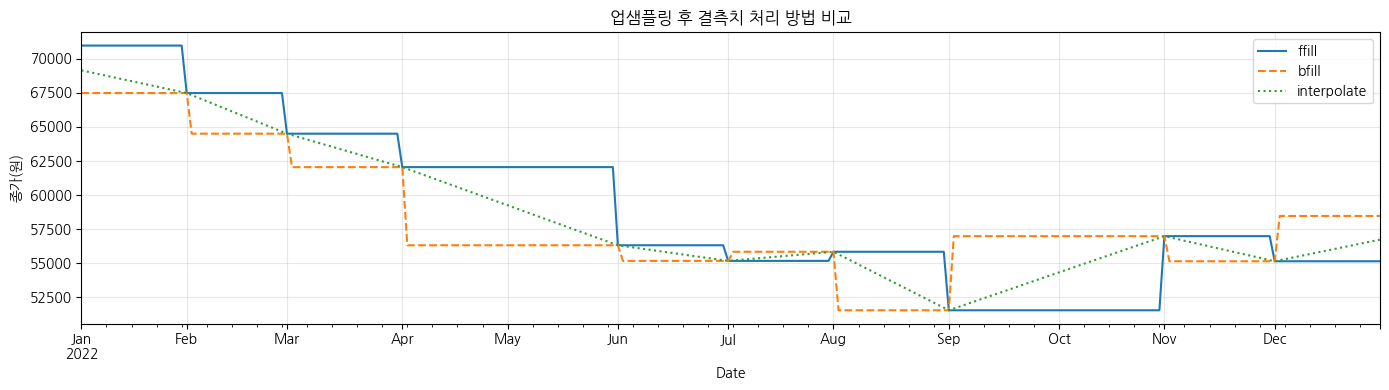

In [43]:
#업샘플링 후 결측치 채우기 3가지 방법
daily_ffill = daily_from_monthly.ffill() #누락된 값을 직전(forward) 유효한 값으로 채움
daily_bfill = daily_from_monthly.bfill() #누락된 값을 직후(backward) 유효한 값으로 채움
daily_interp = daily_from_monthly.interpolate(method='linear') #누락된 값을 주변 유효한 값들을 기준으로 채움

#결과 시각화
fig, axes = plt.subplots(figsize=(14,4))
daily_ffill['2022'].plot(ax=axes, label='ffill', linewidth=1.5)
daily_bfill['2022'].plot(ax=axes, label='bfill', linewidth=1.5, linestyle='--')
daily_interp['2022'].plot(ax=axes, label='interpolate', linewidth=1.5, linestyle=':')
axes.set_title('업샘플링 후 결측치 처리 방법 비교')
axes.set_ylabel('종가(원)')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

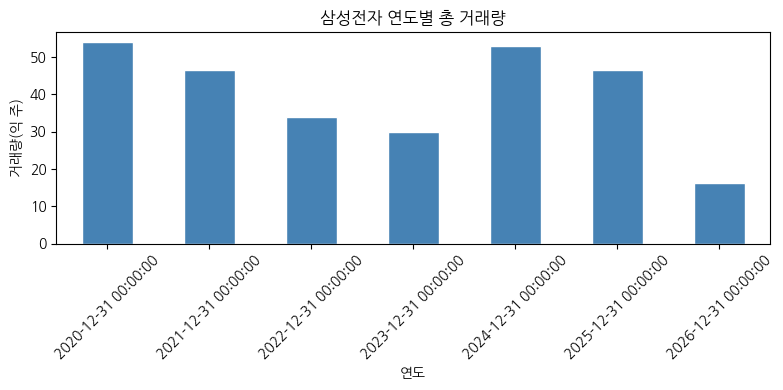

In [44]:
#연도별 거래량 트렌드 시각화
yearly_vol = df_f['Volume'].resample('A').sum() / 1e8 #다운샘플링. 1억 단위('/1e8')로 변환

fig, axes=plt.subplots(figsize=(8,4))
yearly_vol.plot(kind='bar', ax=axes, color='steelblue', edgecolor='white')
axes.set_title('삼성전자 연도별 총 거래량')
axes.set_xlabel('연도')
axes.set_ylabel('거래량(익 주)')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 시간대 다루기

In [58]:
#파이썬 시간대 처리 라이브러리
import pytz

#DataFrame 전체 열에 시간대 적용
df_tz = df_f.copy()
df_tz.index = df_tz.index.tz_localize('Asia/Seoul') #인덱스 전체에 KST 적용
df_tz.head()

#뉴욕 시간으로 변경
df_tz_ny = df_tz.copy()
df_tz_ny.index = df_tz_ny.index.tz_convert('America/New_York')
df_tz_ny.head()

Price,Open,High,Low,Close,Volume,year,month,day,weekday,quarter,dayofyear,weekday_name,days_elapsed,days_int,trading_day
Date,,,,,,,,,,,,,,,
2020-01-01 10:00:00-05:00,47728.892451,48158.882473,47298.902429,47470.898438,12993228,2020,1,2,3,1,2,목,0 days,0,0
2020-01-02 10:00:00-05:00,48158.880631,48674.868637,47212.902618,47728.890625,15422255,2020,1,3,4,1,3,금,1 days,1,1
2020-01-05 10:00:00-05:00,47212.902618,47814.888626,46954.908615,47728.890625,10278951,2020,1,6,0,1,6,월,4 days,4,2
2020-01-06 10:00:00-05:00,47900.892613,48502.878696,47814.894601,47986.890625,10009778,2020,1,7,1,1,7,화,5 days,5,3
2020-01-07 10:00:00-05:00,48330.875289,49362.851274,48072.881293,48846.863281,23501171,2020,1,8,2,1,8,수,6 days,6,4


### 종합 실습 - 삼성전자 주식 시계열 대시보드

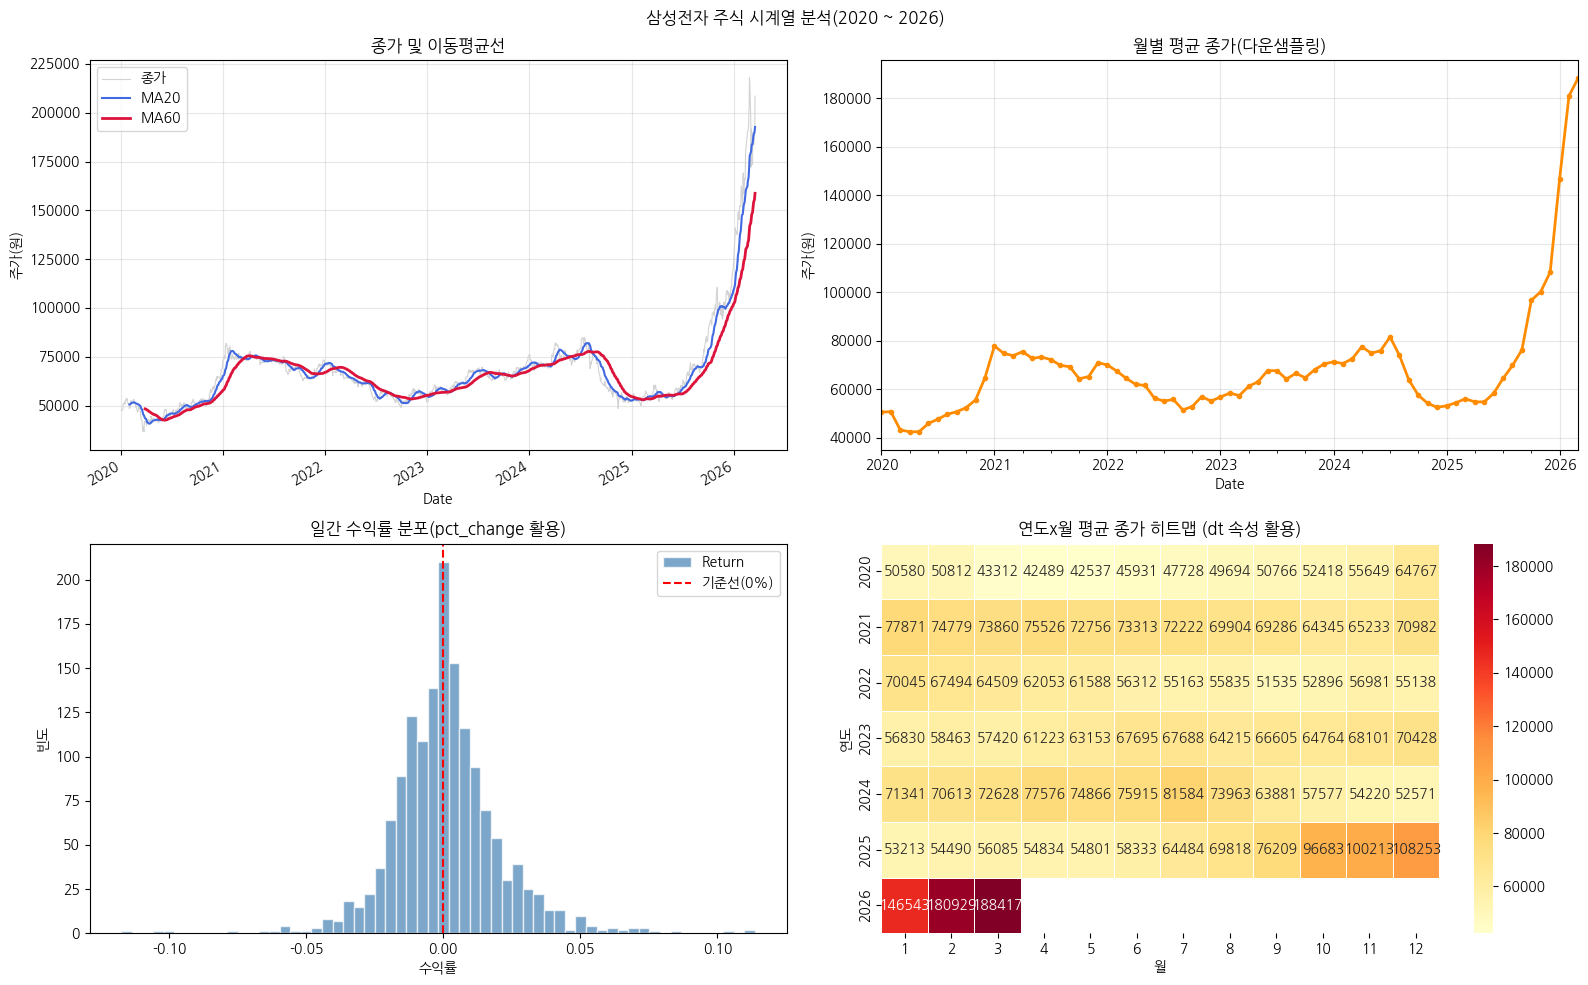

In [56]:
df_all = df_f.copy()

#파생 변수 생성
df_all['MA20'] = df_all['Close'].rolling(20).mean() #20일 이동 평균(20일치 종가의 평균)
df_all['MA60'] = df_all['Close'].rolling(60).mean()
df_all['Return'] = df_all['Close'].pct_change() #일간 수익률 계산(전일 대비 종가 변화율)
df_all['year'] = df_all.index.year
df_all['month'] = df_all.index.month

#대시보드 레이아웃
fig, axes = plt.subplots(2,2,figsize=(16,10))
fig.suptitle('삼성전자 주식 시계열 분석(2020 ~ 2026)')

#[0,0] 종가 + 이동평균선
ax = axes[0][0]
df_all['Close'].plot(ax=ax, color='lightgray', linewidth=0.8, label='종가')
df_all['MA20'].plot(ax=ax, color='royalblue', linewidth=1.5, label='MA20')
df_all['MA60'].plot(ax=ax, color='crimson', linewidth=2, label='MA60')
ax.set_title('종가 및 이동평균선')
ax.set_ylabel('주가(원)')
ax.legend()
ax.grid(True, alpha=0.3)

#[0,1] 월별 평균 종가 (resample 'MS')
ax = axes[0][1]
monthly_avg = df_all['Close'].resample('MS').mean()
monthly_avg.plot(ax=ax, color='darkorange', linewidth=2, marker='o',markersize=3)
ax.set_title('월별 평균 종가(다운샘플링)')
ax.set_ylabel('주가(원)')
ax.grid(True, alpha=0.3)

#[1,0] 일간 수익률 분포 (pct_change + shift 개념)
ax = axes[1][0]
df_all['Return'].dropna().plot(ax=ax, kind='hist', bins=60, color='steelblue',edgecolor='white',alpha=0.7)
ax.axvline(0,color='red', linewidth=1.5, linestyle='--', label='기준선(0%)')
ax.set_title('일간 수익률 분포(pct_change 활용)')
ax.set_xlabel('수익률')
ax.set_ylabel('빈도')
ax.legend()

#[1,1] 연도별 분기 평균 종가 히트맵 (dt 속성 + groupby)
pivot = df_all.pivot_table(values='Close', index='year', columns='month', aggfunc='mean')
sns.heatmap(pivot.round(0),ax=axes[1][1],cmap='YlOrRd',fmt='.0f',annot=True, linewidths=0.5)
axes[1][1].set_title('연도x월 평균 종가 히트맵 (dt 속성 활용)')
axes[1][1].set_xlabel('월')
axes[1][1].set_ylabel('연도')

plt.tight_layout()
plt.show()